In [1]:
print("Hello World!")

Hello World!


In [2]:
import shutil

In [3]:
shutil.move("../../Downloads/train.csv", "train.csv")

'train.csv'

In [ ]:
import pandas as pd

In [18]:
df_tt = pd.read_csv("train.csv")

# 1) df_tt 의 head를 통해 상위 5개 데이터 출력
# 2) df_tt 의 tail을 통해 하위 5개 데이터 출력
# 3) sample()을 통해 랜덤한 3개의 데이터 출력
# 4) info()를 통해 대략적인 정보 확인
# 5) describe()를 통해 통계적인 정보 확인

# df_tt.head()
# df_tt.tail()
# df_tt.sample(3)
df_tt.info()
# df_tt.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# DataFrame을 다루기 위해
# 원본은 남겨두고 복사본으로 연습해보자
df_copy = df_tt.copy()
# 특정 column만 추출하여 새로운 df 만들기 [행, 열]
# df_copy[["PassengerId", "Survived", "Pclass", "Name", "Sex", "Age"]]
df_new = df_copy.loc[ : , "PassengerId" : "Age"]
# df_copy.iloc[ : ,  : 6]

# df_copy에서 나이가 30세 이상인 사람만 추출하여
# df_new2에 담아두기
df_new2 = df_copy.loc[df_copy["Age"] >= 30]
# DataFrame을 csv형태로 export
df_new2.to_csv("exam.csv", index=False)

In [8]:
# 모든 이름을 대문자로 바꾸고 싶다
# 대문자로 변환하는 함수를 정의
# a : 97, z : 122
s = "Hello World!!"
def uppercase(word):
    result = ""
    for w in word:
        if ord("a") <= ord(w) <= ord("z"): # Python은 이게 가능함
            result += chr(ord(w) - (ord("a") - ord("A")))
        else:
            result += w
    return result
uppercase(s)

'HELLO WORLD!!'

In [9]:
def to_uppercase(word):
    return word.upper()

# df의 특정 칼럼에 data를 수정하고 싶을 때
# 수정 관련된 함수를 정의!!
# df_copy는 깊은 복사라 원본 변동이 없지만
# df_new는 바꾸면 df_copy가 바뀌는 얕은 복사

# 특정 컬럼 인덱싱.apply(적용할 함수명)
df_new["Name"] = df_new["Name"].apply(to_uppercase)
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"BRAUND, MR. OWEN HARRIS",male,22.0
1,2,1,1,"CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...",female,38.0
2,3,1,3,"HEIKKINEN, MISS. LAINA",female,26.0
3,4,1,1,"FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)",female,35.0
4,5,0,3,"ALLEN, MR. WILLIAM HENRY",male,35.0
...,...,...,...,...,...,...
886,887,0,2,"MONTVILA, REV. JUOZAS",male,27.0
887,888,1,1,"GRAHAM, MISS. MARGARET EDITH",female,19.0
888,889,0,3,"JOHNSTON, MISS. CATHERINE HELEN ""CARRIE""",female,NaN
889,890,1,1,"BEHR, MR. KARL HOWELL",male,26.0


In [4]:
df_new["Name"] = df_new["Name"].apply(lambda word : word.lower())
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"braund, mr. owen harris",male,22.0
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0
2,3,1,3,"heikkinen, miss. laina",female,26.0
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0
4,5,0,3,"allen, mr. william henry",male,35.0
...,...,...,...,...,...,...
886,887,0,2,"montvila, rev. juozas",male,27.0
887,888,1,1,"graham, miss. margaret edith",female,19.0
888,889,0,3,"johnston, miss. catherine helen ""carrie""",female,NaN
889,890,1,1,"behr, mr. karl howell",male,26.0


In [ ]:
# Pclass가 현재 1, 2, 3
# 10, 20, 30
# df_new["Pclass"] = df_new["Pclass"].apply(lambda num : num / 10)

# 1 -> 생존, 0 -> 사망
# df_new["Survived"].apply(lambda x : "생존" if x == 1 else "사망")

# Pclass가 1이면 퍼스트 2면 비즈니스 3이면 이코노미
# 맵핑하는 딕셔너리 생성
pclass_map = {1:"퍼스트", 2:"비즈니스", 3:"이코노미"}
df_new["Pclass"].map(pclass_map)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


In [ ]:
# Lambda Expression
# 함수를 정의하지 않아도 사용 가능
def add(num1, num2):
    return num1 + num2
add(3, 5) # 하나 풀기 위해 함수정의는 낭비

(lambda num1, num2 : num1 + num2)(30, 50)

80

In [14]:
df_new3 = df_new.copy()
# 비어 있는 데이터 : 결측치(NaN)
# dropna() -> 데이터가 없는 행 삭제
# inplace는 적용된 내용을 원본에 반영!!
df_new3.dropna(inplace=True)
df_new3

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"BRAUND, MR. OWEN HARRIS",male,22.0
1,2,1,1,"CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...",female,38.0
2,3,1,3,"HEIKKINEN, MISS. LAINA",female,26.0
3,4,1,1,"FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)",female,35.0
4,5,0,3,"ALLEN, MR. WILLIAM HENRY",male,35.0
...,...,...,...,...,...,...
885,886,0,3,"RICE, MRS. WILLIAM (MARGARET NORTON)",female,39.0
886,887,0,2,"MONTVILA, REV. JUOZAS",male,27.0
887,888,1,1,"GRAHAM, MISS. MARGARET EDITH",female,19.0
889,890,1,1,"BEHR, MR. KARL HOWELL",male,26.0


In [11]:
df_new4 = df_new.copy()
# 결측치 채우는 통계적 방법(평균, 중앙)
# NaN값들을 Age의 평균으로 채워보자
age_mean = df_new4["Age"].mean()
df_new4["Age"] = df_new4["Age"].fillna(age_mean)
df_new4

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000
4,5,0,3,"Allen, Mr. William Henry",male,35.000000
...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000


In [13]:
df_new5 = df_new.copy()
# 없는 컬럼을 넣으면 추가됨 - 있으면 수정
df_new5["Gender"] = df_new5["Sex"].apply(lambda x : "남성" if x == "male" else "여성")
df_new5

,PassengerId,Survived,Pclass,Name,Sex,Age,Gender
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,남성
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,여성
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,여성
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,여성
4,5,0,3,"Allen, Mr. William Henry",male,35.0,남성
...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,남성
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,여성
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,여성
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,남성


In [30]:
# 0) Survived, Pclass, Name, Sex, Age, Embarked 컬럼만 인덱싱하기
df_exam = df_copy[["Survived", "Pclass", "Name", "Sex", "Age", "Embarked"]].copy()

# 1) Sex를 모두 대문자로 바꿔주세요
df_exam["Sex"] = df_exam["Sex"].apply(lambda word : word.upper())

# 2) Age 결측치(NaN)를 중앙값(Midean)으로 채워주세요 - 28
age_midean = df_exam["Age"].median()
df_exam["Age"] = df_exam["Age"].fillna(age_midean)
# age_midean = 28 # 직접 넣은거라 전문성 떨어짐

# 3) Pclass가 1이면 1등급, 2면 2등급, 3이면 3등급으로 바꿔주세요
df_exam["Pclass"] = df_exam["Pclass"].apply(lambda x : f"{x}등급")
# pclass_map = {1:"1등급", 2:"2등급", 3:"3등급"}
# df_exam["Pclass"] = df_exam["Pclass"].map(pclass_map)

# 4) Embarked가 항구이므로 S항구, C항구, Q항구로 바꿔주세요
df_exam["Embarked"] = df_exam["Embarked"].apply(lambda x : f"{x}항구")
# embarked_map = {"S":"S항구", "C":"C항구", "Q":"Q항구"}
# df_exam["Embarked"] = df_exam["Embarked"].map(embarked_map)

# 5) 새로운 컬럼 추가!! 이름은 "생존여부"
#     Survived가 1이면 -> "O", 0이면 "X"값을 가지는 새로운 컬럼!!
df_exam["생존여부"] = df_exam["Survived"].apply(lambda x : "O" if x == 1 else "X")

df_exam

,Survived,Pclass,Name,Sex,Age,Embarked,생존여부
0,0,3등급,"Braund, Mr. Owen Harris",MALE,22.0,S항구,X
1,1,1등급,"Cumings, Mrs. John Bradley (Florence Briggs Th...",FEMALE,38.0,C항구,O
2,1,3등급,"Heikkinen, Miss. Laina",FEMALE,26.0,S항구,O
3,1,1등급,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FEMALE,35.0,S항구,O
4,0,3등급,"Allen, Mr. William Henry",MALE,35.0,S항구,X
...,...,...,...,...,...,...,...
886,0,2등급,"Montvila, Rev. Juozas",MALE,27.0,S항구,X
887,1,1등급,"Graham, Miss. Margaret Edith",FEMALE,19.0,S항구,O
888,0,3등급,"Johnston, Miss. Catherine Helen ""Carrie""",FEMALE,28.0,S항구,X
889,1,1등급,"Behr, Mr. Karl Howell",MALE,26.0,C항구,O


In [32]:
# 시각화 : matplotlib : 데이터를 다양한 방법으로 도식화하는 라이브러리
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 시각화 : matplotlib : 데이터를 다양한 방법으로 도식화하는 라이브러리
import matplotlib.pyplot as plt

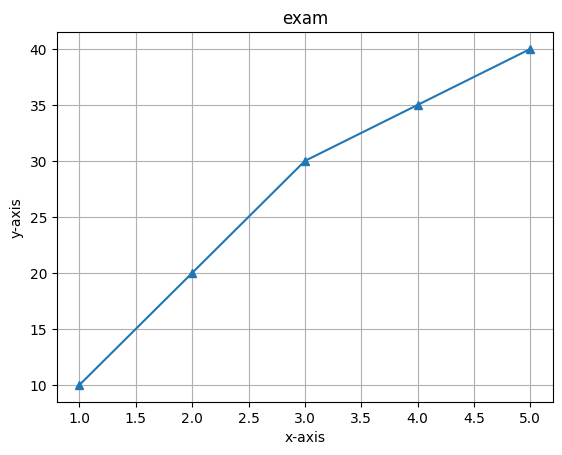

In [9]:
# 1) 선 그래프 : Line Plot
x = [1,2,3,4,5]
y = [10,20,30,35,40]

plt.plot(x, y, marker="^")
plt.title("exam")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.grid(True)
plt.show()

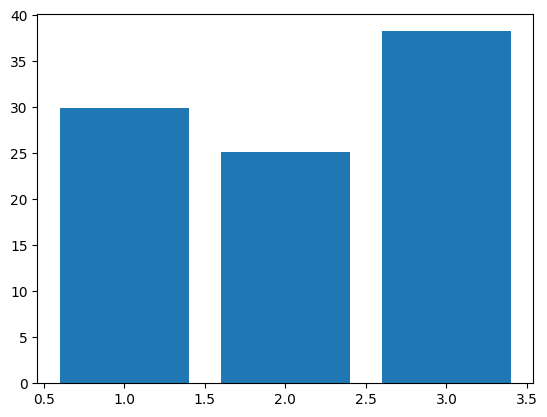

In [14]:
# 2) Bar Plot
# 객실 등급별 평균 연령을 막대 그래프
x_bar = df_new["Pclass"].unique()
y_bar = df_new.groupby("Pclass")["Age"].mean()

plt.bar(x_bar, y_bar)
plt.show()

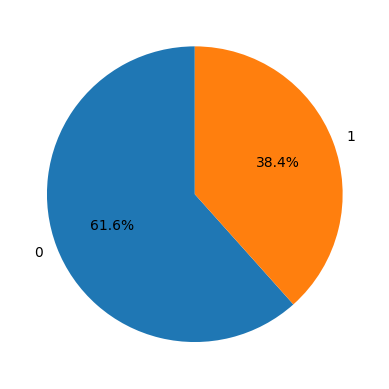

In [20]:
# 3) Pie Chart
# 생존 여부
alive = df_new["Survived"].value_counts()
plt.pie(alive, startangle=90, labels=alive.index, autopct="%.1f%%")
plt.show()

In [ ]:
# 연습
# 1) Sex별에 따른 생존 개수 bar plot
# 2) Pclass를 Pie Chart로 시각화

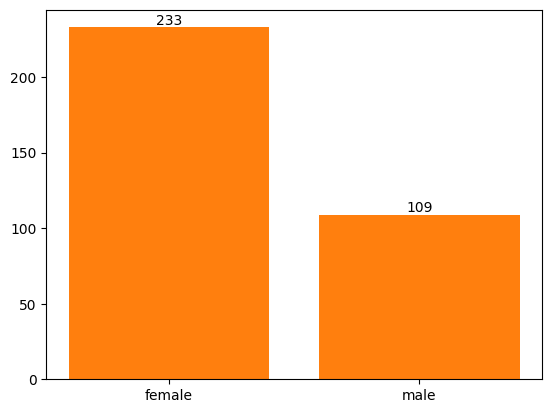

In [38]:
# 1) Sex별에 따른 생존 개수 bar plot
x_bar = df_new["Sex"].unique()
# y_bar = df_new.groupby("Sex")["Survived"].sum()
y_bar = df_new[df_new["Survived"] == 1].groupby("Sex")["Survived"].count()
bars = plt.bar(y_bar.index, y_bar.values)
plt.bar(y_bar.index, y_bar.values)
plt.bar_label(bars)
plt.show()


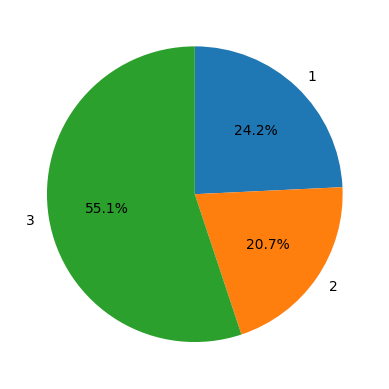

In [41]:
# 2) Pclass를 Pie Chart로 시각화
p_class = df_new["Pclass"].value_counts()
p_class = p_class.sort_index()
plt.pie(p_class, labels=p_class.index, startangle=90, autopct="%.1f%%", counterclock=False)
plt.show()

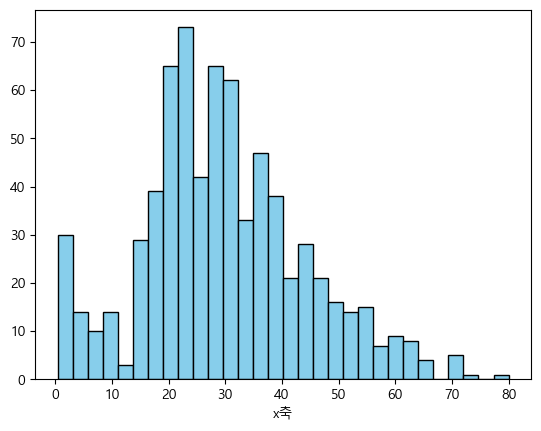

In [47]:
# 히스토그램
# 승객의 나이 분포를 확인해보자
df_new6 = df_new["Age"].dropna()
plt.hist(df_new6, bins=30, edgecolor="black", color= "skyblue")
plt.xlabel("x축")
plt.show()

In [59]:
# 상관계수(Correlation Coefficient)
# 비가 오면 편의점 우산 판매량이 증가한다

# corr 적용하기 위해 int나 float 형식으로 변경하기
# Sex컬럼이 male이라면 0, female이면 1로 변환
# df_new["Sex"] = df_new["Sex"].apply(lambda x : 0 if x == "male" else 1)
df_corr = df_new[["Survived", "Pclass", "Sex", "Age"]]
df_corr.corr()
# 상관관계 계수 [ +1 ~ -1 ]
# +로 갈수록 양의 상관관계 -> 비례
# -로 갈수록 음의 상관관계 -> 반비례
# Survived ~ Pclass : 객실 등급이 높을수록(3) 생존률 감소
# Survived ~ Sex : 0.5니까 굉장히 영향 높음, 여성이면 생존

,Survived,Pclass,Sex,Age
Survived,1.000000,-0.338481,0.543351,-0.077221
Pclass,-0.338481,1.000000,-0.131900,-0.369226
Sex,0.543351,-0.131900,1.000000,-0.093254
Age,-0.077221,-0.369226,-0.093254,1.000000


In [61]:
df_poke = pd.read_csv("pokemon.csv")
df_poke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          1215 non-null   int64 
 1   Name        1215 non-null   object
 2   Form        1215 non-null   object
 3   Type1       1215 non-null   object
 4   Type2       1215 non-null   object
 5   Total       1215 non-null   int64 
 6   HP          1215 non-null   int64 
 7   Attack      1215 non-null   int64 
 8   Defense     1215 non-null   int64 
 9   Sp. Atk     1215 non-null   int64 
 10  Sp. Def     1215 non-null   int64 
 11  Speed       1215 non-null   int64 
 12  Generation  1215 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 123.5+ KB


In [ ]:
!pip3 install seaborn
%pip install seaborn
import seaborn as sns

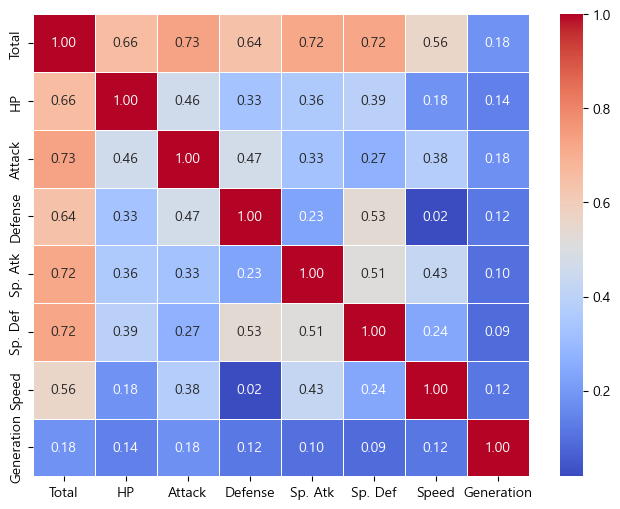

In [81]:
# Generation, Total, Speed
poke_corr = df_poke[["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(poke_corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.show()

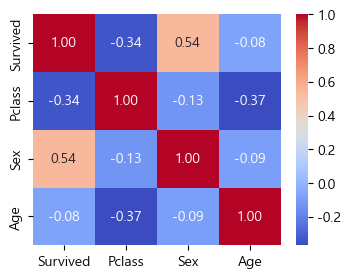

In [79]:
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(4, 3))
sns.heatmap(df_corr.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

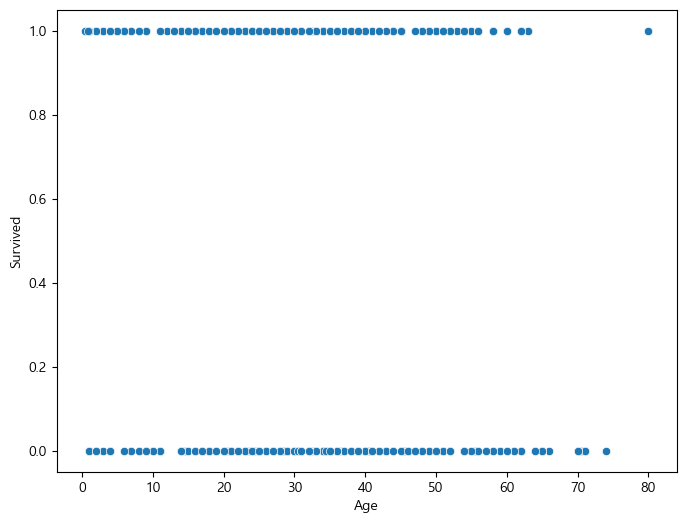

In [83]:
# 산점도
plt.figure(figsize=(8, 6))
sns.scatterplot(df_new, x="Age", y="Survived")
plt.show()

In [ ]:
# 머신 러닝 기초
# Rule-Based expert system
# if 와 else로 하드코딩하던 시절이 있었음 (ex. Simsimi, 스팸 필터)
# 규칙을 설계하려면 기반 지식이 필요했음
# 작업이 조금만 변경되어도 전체 시스템을 다시 제작 - 그 자체도 오래 걸림
# 아직 일어나지 않은 
# 스타벅스
# 20살 -> 아메리카노
# 23살 -> 라떼
# 25살 -> 카푸치노
# 27살 -> 모카
# 20살이 오면 계속 아메리카노
# 새로운 패턴이 생긴다면? input 예측이 불가

# 아직 일어나지 않은 미지의 일을 예측하기 위해
# 데이터와 답을 토대로 규칙을 찾는 행위
# 규칙을 사람이 찾아 기계에게 : 일반적인 컴퓨터 사이언스
# 데이터와 결과를 알려주고 기계한테 규칙을 찾도록 : 머신 러닝

# 머신러닝 종류
# 지도 학습 : Supervised Learning
# 비지도 학습 : Unsupervised Learning 
# 강화 학습** : Reinforcement Learning

In [85]:
# 지도학습
# 데이터에 대한 Label(명시적인 답)이 주어진 상태에서 학습
# 분류(Classification - y가 범주형 데이터) 와 회귀(Regression - y가 수치 데이터)
# 분류 - Classification
# 미리 정의된 여러 클래스 레이블 중 하나를 예측하는 것
# 속성 값을 입력, 클래스 값을 출력으로 하는 모델
# 이진 분류, 다중 분류 등이 있음

In [ ]:
# 비지도학습
# 데이터에 대한 Label이 없는 상태에서 학습
# 데이터의 숨겨진 특징, 구조, 패턴을 파악하는데 사용
# 데이터를 비슷한 특성끼리 묶는 클러스터링(Clustering)과 차원 축소(Dimensionality Reduction) 등등
#                              ㄴ군집
# 데이터도 연속 데이터 & 이산 데이터 등이 있음

In [ ]:
# 강화학습 - 주로 게임이나 로봇
# 지도 학습과 비슷하지만 완전한 답을 주지 않음
# 더 많은 보상을 얻을 수 있는 방향으로 행동을 학습

In [87]:
!pip3 install scikit-learn
%pip install scikit-learn
import sklearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 머신 러닝 기초(Machine Learing Basic)
# 등장 이유 : 데이터 폭증, 컴퓨팅 파워의 증가

# ex. 공부시간에 따른 성적을 예측!!
# 용어
# Feature(특성) : Model의 입력값 X (예 : 공부시간)
# Label(레이블/정답) : Model이 예측해야 되는 값 y (예 : 성적)
# Training(학습) : Feature와 Label을 통해 Model을 만들어가는 과정
# Inference(추론) : 학습된 Model을 통해 새로운 입력값의 Label을 예측하는 과정

In [104]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

# dataset의 key
iris_dataset.keys()

# iris의 품종
iris_dataset["target_names"]

# iris의 특징
iris_dataset["feature_names"]

# data의 종류 - type = numpy.ndarray
iris_dataset["data"]

# data의 크기: 150개 데이터, 4개의 feature
iris_dataset["data"].shape

# 상위 5개 데이터
iris_dataset["data"][ : 5]

# 지도학습!! -> Label
iris_dataset["target"]

# Label의 data 타입 = numpy.ndarray
type(iris_dataset["target"])

# Label의 개수: 150개 데이터, 1차원
iris_dataset["target"].shape

print(iris_dataset.keys())
print("품종 :", iris_dataset["target_names"])
print("특징 이름 :", iris_dataset["feature_names"])
print("데이터 타입 :", type(iris_dataset["data"]))
print("데이터 크기 :", iris_dataset["data"].shape)
print("첫 5개 데이터 :\n", iris_dataset["data"][:5])
print("Label : \n", iris_dataset["target"])
print("Label 데이터 타입 :", type(iris_dataset["target"]))
print("Label 개수 :", iris_dataset["target"].shape)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
품종 : ['setosa' 'versicolor' 'virginica']
특징 이름 : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
데이터 타입 : <class 'numpy.ndarray'>
데이터 크기 : (150, 4)
첫 5개 데이터 :
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Label : 
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Label 데이터 타입 : <class 'numpy.ndarray'>
Label 개수 : (150,)


In [118]:
# 150개의 X (Input)
# 150개의 y (Label)
# 학습

# 모델이 잘 예측하는지 확인!! : 평가
# 150개

# 데이터를 분할
# 학습 : 테스트 비율, 0.8~0.7 : 0.2~0.3 정도로 구분
# 148개는 학습, 2개는 테스트
# 테스트 : 정답이 있는 데이터를 모델에 예측한 결과와 실제 정답간 비교

# 새로운 데이터?? 

# 학습 : 테스트 데이터를 분리
# X = iris_dataset["data"] 동일
X = iris_dataset.data
y = iris_dataset.target
# 단 이렇게 분리하면 데이터가 편향되어 분리될 수 있음

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)
# 실행할때마다 달라짐, random_state는 시드라 고정시키면 항상 동일

0.25333333333333335

In [121]:
# KNN 최근접 이웃 알고리즘
# 나랑 가까운 이웃 3명을 보고
# 나를 결정!!! (예 : 강아지2, 고양이1 -> 나는 강아지)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
# 학습 fit
# 학습 시 주의사항!!
# 절대... Test Dataset을 건드리면 안됨
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [125]:
# 학습된 모델을 평가해보자!!
# Test 데이터셋을 가지고

# 학습된 knn모델에 X_test를 넣어 예측 결과를 y_pred에 저장
y_pred = knn.predict(X_test)
# 우리가 만든 모델을 통해 예측된 결과
print(f"우리가 만든 모델을 통해 예측된 결과 : \n{y_pred}")
print(f"정답 결과 : \n{y_test}")

# y_pred와 y_test의 값을 비교하여
# 얼마나 정확한지(accuracy) 확인해보자
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 :{accuracy * 100 : .2f}%")

우리가 만든 모델을 통해 예측된 결과 : 
[0 1 1 2 1 1 2 0 2 0 2 1 1 0 0 2 0 1 2 1 1 2 2 0 2 1 1 0 2 2 1 1 0 0 0 1 1
 0]
정답 결과 : 
[0 1 1 2 1 1 2 0 2 0 2 1 2 0 0 2 0 1 2 1 1 2 2 0 1 1 1 0 2 2 1 1 0 0 0 2 1
 0]
정확도 : 92.11%


[0.947, 0.947, 0.974, 0.974, 0.974, 0.974, 0.974, 1.0, 0.974, 1.0, 1.0, 1.0, 0.974, 1.0]


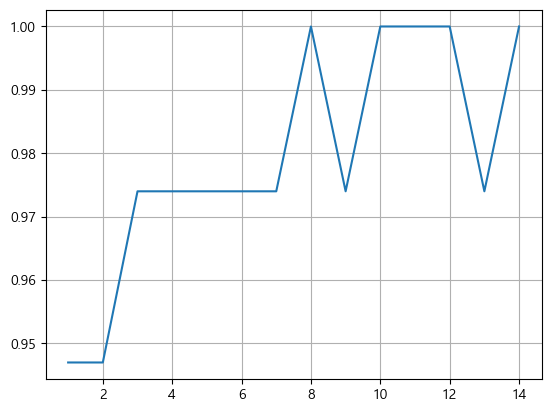

In [141]:
accuracies = []
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)
for i in range(3, 30, 2):    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = round(accuracy_score(y_test, y_pred), 3)
    accuracies.append(accuracy)
print(accuracies)
# 너무 이웃이 많으면 오히려 정확도가 떨어짐
x_line = list(range(1, len(accuracies) + 1))
y_line = accuracies
plt.plot(x_line, y_line)
plt.grid(True)
plt.show()

In [ ]:
# 모델의 성능

# 과소적합(Underfitting)
# 예를 들어 정확도 0.7 -> 모델의 예측확률이 낮다
# 규칙, 패턴이 단순해서 예측하기 어려울 수 있다.
# 학습 성능 낮다, 테스트 성능 낮다

# 과대적합(Overfitting)
# ex. 랜덤 스테이트 : 42 -> 100% 정확도
# 데이터셋은 기가막히게 맞추는데
# 실 데이터(test data)는 잘 맞추지 못함
# 학습 성능 높다, 테스트 성능 낮다

# 일반화(Generalization) <- 추구하는 방향
# 모델이 학습, 테스트도 잘 통과

# 과소적합 -> feature를 추가!!, 더 복잡한 모델 사용
# 과대적합 -> 데이터 정제, Feature 제한, 교차-검증

In [ ]:
# 2번째 분류 모델
# 의사 결정 트리(Decision Tree)
# Feature에 대한 질문을 통해 데이터를 분류
# 정보 획득이 최대가 되는 방향으로 Feature에 대한 질문을 한다!

from sklearn.datasets import load_wine # 와인 데이터
from sklearn.tree import DecisionTreeClassifier # 의사 결정 트리 분류 모델
from sklearn.model_selection import train_test_split # 훈련, 테스트 분리
from sklearn.metrics import accuracy_score # 평가지표 : 정확도

In [ ]:
wine_dataset = load_wine()
print("key : ", wine_dataset.keys())
print("data : ", wine_dataset.data[:2])
print("target : ", wine_dataset.target)
print("target_names : ", wine_dataset.target_names)
print("feature_names : ", wine_dataset.feature_names)

In [161]:
wine_dataset = load_wine()
X = wine_dataset.data
y = wine_dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)
tree = DecisionTreeClassifier(max_depth=3, random_state=20)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy * 100: .2f}%")

정확도 :  88.89%


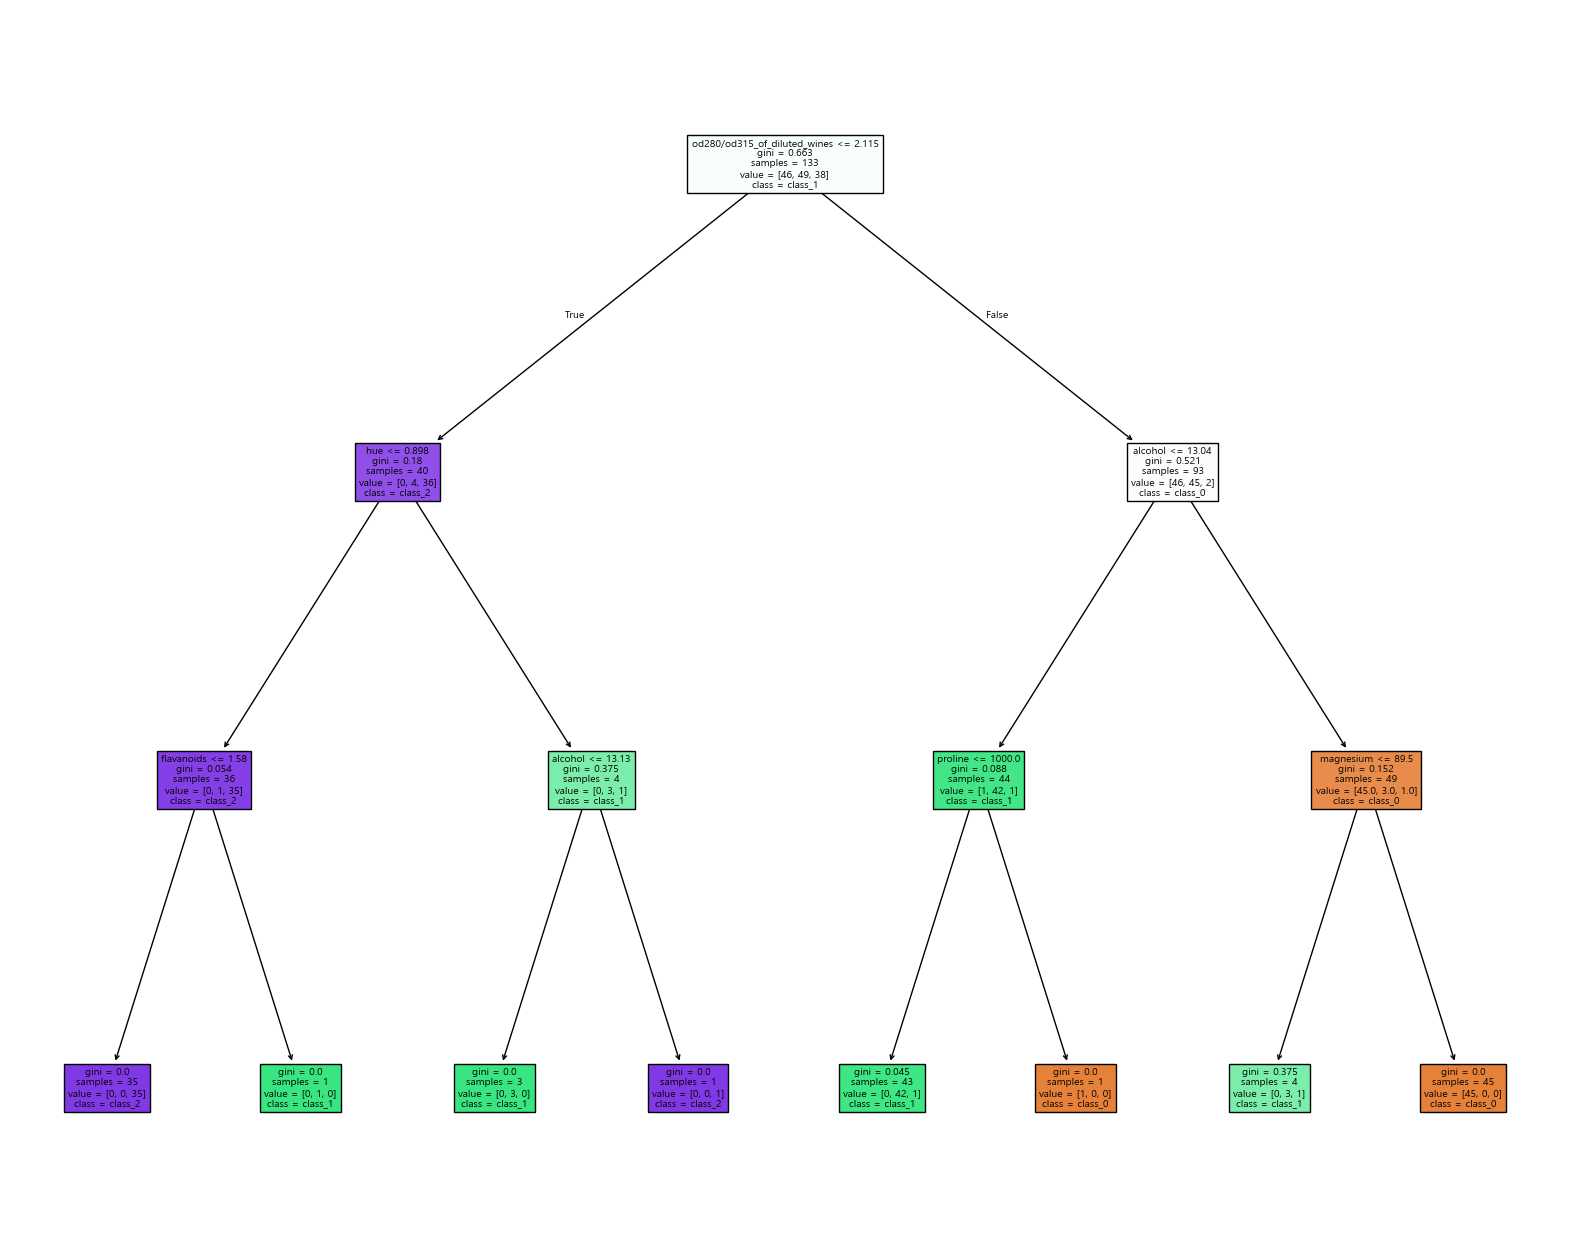

In [ ]:
# 의사 결정 트리 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(20,16))
plot_tree(tree, feature_names=wine_dataset.feature_names, filled=True, class_names=wine_dataset.target_names)
plt.show()

In [ ]:
# 2번째 분류 모델
# 의사 결정 트리(Decision Tree)
# Feature에 대한 질문을 통해 데이터를 분류
# 정보 획득이 최대가 되는 방향으로 Feature에 대한 질문을 한다!

# 핵심 개념
# 불순도(Impurity) : 한 노드에 여러 클래스가 얼마나 섞여 있는지 나타내는 정도
# gini 불순도 : 클래스가 섞여 있지 않을수록 0.0에 수렴
# 엔트로피 : 클래스가 얼마나 안정되어 있는지
# 정보 획득(Information Gain) : 특정 질문을 통해 데이터를 나누었을 때
#                              불순도가 얼마나 감소하는지

# 장점
# 시각화!! : 눈으로 보인다
# 사람의 언어로 표현하기 용이
# 전처리가 쉽다

# 단점
# 과대적합 확률 굉장히 높다 -> max_depth 제한,하나의 노드에 들어가는 최소 개수 제한
#                                            ㄴ1제안에 최소한 5개가 걸러지도록
# train_data에 영향을 많이 받는다
# -> split에 따라 모델 성능이 크게 좌우됨

# 하나의 상자에 공이 10개 들어있다
# 빨간 공 5개, 파란 공 5개
# 2개의 공을 꺼내면 -> 둘 다 빨강(22.5), 둘 다 파랑(22.5) //// 빨강+파랑 (55%?)

# 클래스가 순수(Pure)
# 빨간 공 10개
# 다른 색 나올 확률이 0 퍼센트

In [ ]:
# 어떤 feature가 영향을 가장 많이 미치는가?
tree_importance = tree.feature_importances_
data = {"feature":wine_dataset.feature_names, "importance":tree_importance}
df_wine = pd.DataFrame(data)
df_wine.sort_values(by=["importance"], ascending=[False])

,feature,importance
0,alcohol,0.455547
11,od280/od315_of_diluted_wines,0.384179
4,magnesium,0.070454
10,hue,0.044325
6,flavanoids,0.022950
12,proline,0.022545
3,alcalinity_of_ash,0.000000
1,malic_acid,0.000000
2,ash,0.000000
8,proanthocyanins,0.000000


In [ ]:
# 유방암 데이터를 의사 결정 트리로 분류해보자

# 1) 의사결정나무 클래스 import
# 2) dataset import
# 3) train_test_split import
# 4) accuracy import

# 5) load_breast_cancer를 통해 cancer 인스턴스 생성
# cancer.keys()를 통해 어떤 데이터 타입, 개수, 클래스 이름 등 확인

# 6) X, y 설정!!
# 7) train과 test 분할(분리)
# 8) 의사 결정 나무 클래스를 통해 d_tree 인스턴스 생성, 단 max_depth=3, random_state=20
# 9) 학습!! -> fit(학습)
# 10) 학습된 모델에 X_test 넣어 y_pred 예측!!
# 11) y_pred, y_test 비교해서 정확도(accuracy) 측정

# 12) plot_tree 통해 시각화!!

# 13) 어떤 요인이 영향을 미쳤는지?(importance) 확인!!


import sklearn
from sklearn.tree import DecisionTreeClassifier


from sklearn.datasets import load_breast_cancer

In [ ]:
# 1) 의사결정나무 클래스 import
# 2) dataset import
# 3) train_test_split import
# 4) accuracy import
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [179]:
# 5) load_breast_cancer를 통해 cancer 인스턴스 생성
# cancer.keys()를 통해 어떤 데이터 타입, 개수, 클래스 이름 등 확인
cancer = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [182]:
print("key : ", cancer.keys())
print("data : ", cancer.data[:2])
print("target : ", cancer.target)
print("target_names : ", cancer.target_names)
print("feature_names : ", cancer.feature_names)

key :  dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
data :  [[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]]
target :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 

In [ ]:
# 6) X, y 설정!!
X = cancer.data
y = cancer.target

# 7) train과 test 분할(분리)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)

# 8) 의사 결정 나무 클래스를 통해 d_tree 인스턴스 생성, 단 max_depth=3, random_state=20
d_tree = DecisionTreeClassifier(max_depth=3, random_state=20)

# 9) 학습!! -> fit(학습)
d_tree.fit(X_train, y_train)

# 10) 학습된 모델에 X_test 넣어 y_pred 예측!!
y_pred = d_tree.predict(X_test)

# 11) y_pred, y_test 비교해서 정확도(accuracy) 측정
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy * 100: .2f}%")

정확도 :  90.21%


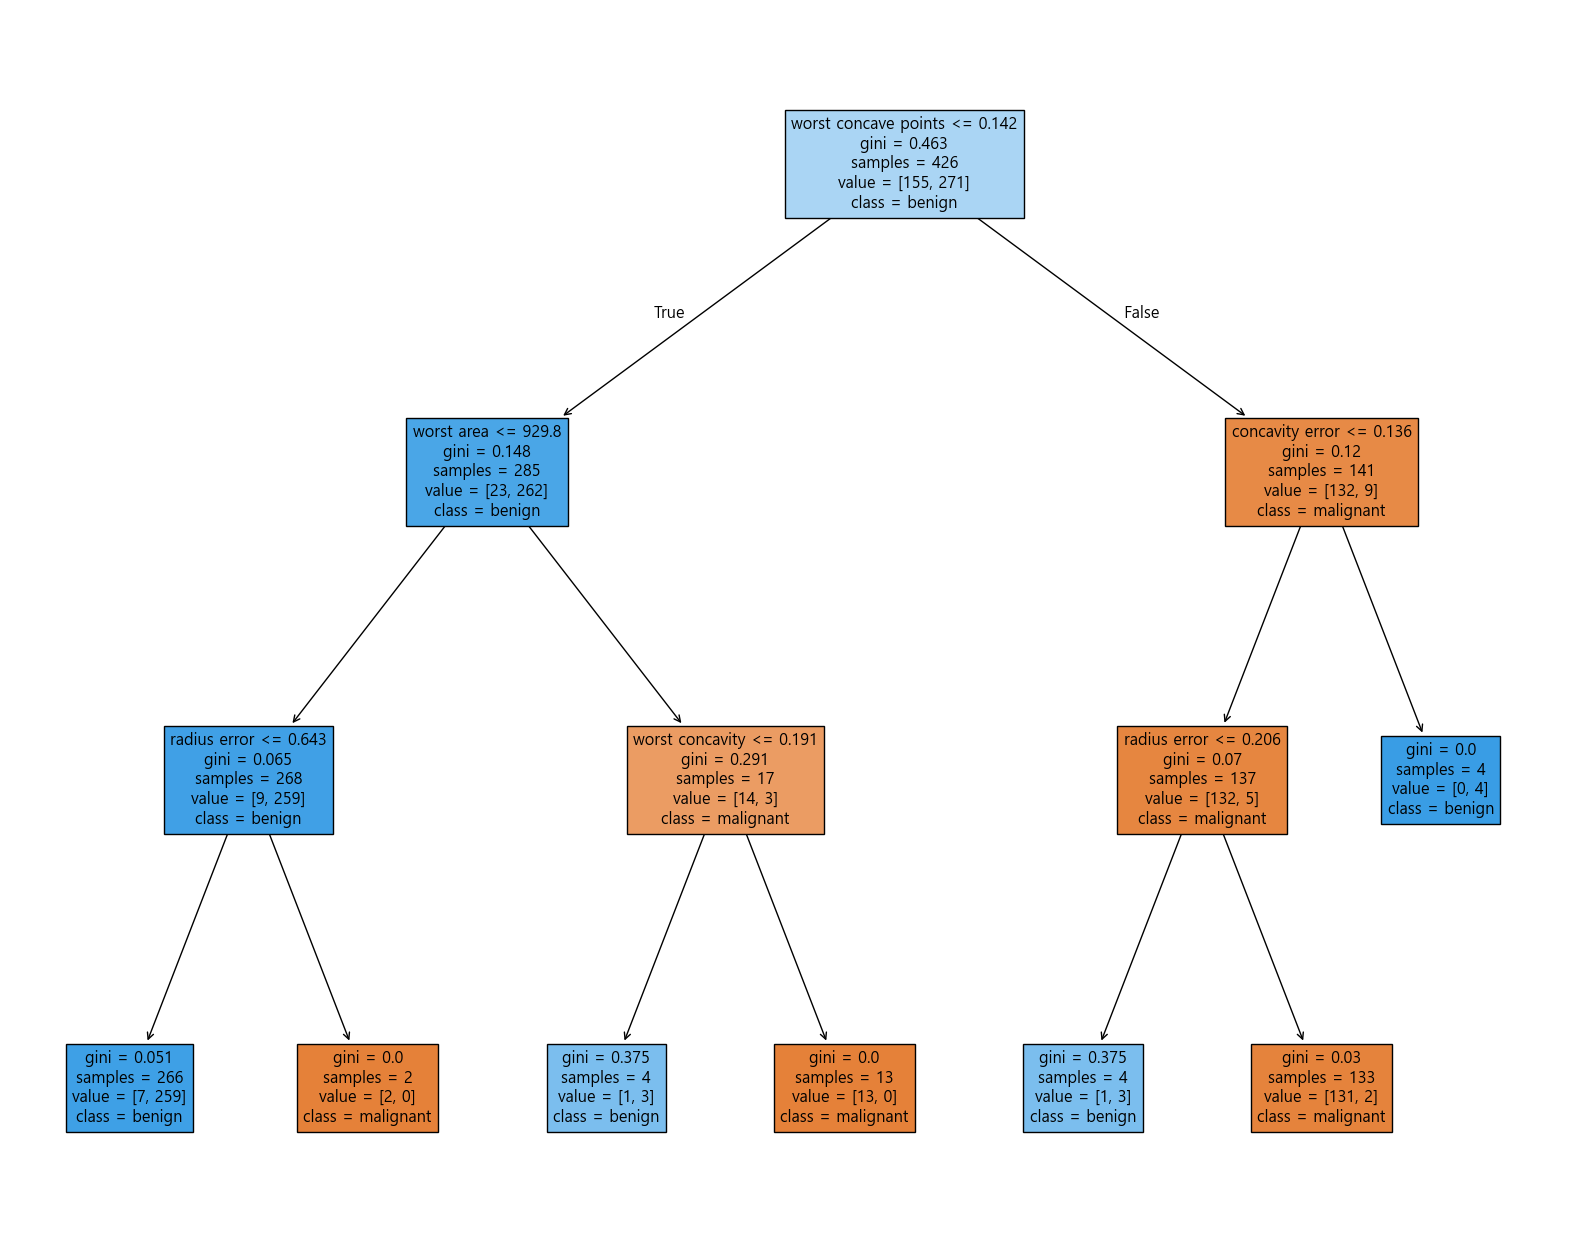

In [191]:
# 12) plot_tree 통해 시각화!!

plt.figure(figsize=(20,16))
plot_tree(d_tree, feature_names=cancer.feature_names, filled=True, class_names=cancer.target_names)
plt.show()

In [192]:
# 13) 어떤 요인이 영향을 미쳤는지?(importance) 확인!!
d_tree_importance = d_tree.feature_importances_
data = {"feature":cancer.feature_names, "importance":d_tree_importance}
df_cancer = pd.DataFrame(data)
df_cancer.sort_values(by=["importance"], ascending=[False])

,feature,importance
27,worst concave points,0.781655
23,worst area,0.112950
10,radius error,0.045060
16,concavity error,0.040853
26,worst concavity,0.019482
0,mean radius,0.000000
5,mean compactness,0.000000
6,mean concavity,0.000000
8,mean symmetry,0.000000
7,mean concave points,0.000000


In [ ]:
# 데이터 정리
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# df_tt = pd.read_csv("train.csv")

# 폰트
# import matplotlib.font_manager as fm
# font_path = 'C:/Windows/Fonts/MALGUN.TTF'
# font_name = fm.FontProperties(fname=font_path).get_name()
# plt.rc('font', family=font_name)
# plt.rcParams['axes.unicode_minus'] = False

# 머신러닝
# import sklearn

# 의사 결정 트리
from sklearn.datasets import load_wine # 와인 데이터
from sklearn.tree import DecisionTreeClassifier # 의사 결정 트리 분류 모델
from sklearn.model_selection import train_test_split # 훈련, 테스트 분리
from sklearn.metrics import accuracy_score # 평가지표 : 정확도
from sklearn.tree import plot_tree

wine_dataset = load_wine()
X = wine_dataset.data
y = wine_dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)
tree = DecisionTreeClassifier(max_depth=3, random_state=20)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

tree_importance = tree.feature_importances_

